In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as spst

from statsmodels.formula.api import ols, logit, poisson, negativebinomial
from statsmodels.base.model import GenericLikelihoodModel

This [case study](https://docs.google.com/document/d/1z6AmUW_vYi0HZT1XcPxe74h-uBRPRizXSVcuIrRMW88/edit) investigates the effect of sending coupon promotions to prospective customers of an online store. An A/B test is conducted by sending a nontransferrable coupon to half of the customer group, randomly selected, and sending the other half nothing at all. The result of this test is the following data set. Please refer to the document for descriptions of the data set columns.

In [2]:
ABtest = pd.read_csv("AB_test.csv")
ABtest

,id,trans_after,revenue_after,test_coupon,channel_acq,num_past_purch,spent_last_purchase,weeks_since_visit,browsing_minutes,shopping_cart
0,6001,0,0.00,0,2,6,62.99,6,1,0
1,6002,0,0.00,1,1,2,53.99,0,7,1
2,6003,0,0.00,1,2,3,88.98,3,4,0
3,6004,0,0.00,0,2,1,68.99,1,19,0
4,6005,0,0.00,1,3,3,66.49,4,20,0
...,...,...,...,...,...,...,...,...,...,...
4995,10996,1,51.49,0,2,3,51.49,1,9,1
4996,10997,0,0.00,1,1,0,0.00,3,8,0
4997,10998,0,0.00,1,1,1,60.49,4,17,0
4998,10999,0,0.00,1,1,0,0.00,2,14,1


Let's try to address each of the following questions.

1. Can we verify whether the coupon assignment was random?

2. Was the strategy effective or not? What was the effect of the coupon assignments on revenues and transactions?

3. If you were a manager, would you want to send coupons to all customers? If not, which customers should receive a coupon? 

# Randomness of Group Assignment

To test randomness of group assignments, we can try to fit a model regressing **test_coupon**, the group assigned to each customer, on all of the other factors except for **trans_after** and **revenue_after**. If the group assignments were truly random, we should find that the estimated parameters are all *statistically insignificant*. In other words, these factors should have no impact on which group a customer is assigned to, meaning that the null hypothesis ($\beta_i=0$) holds.

Since **test_coupon** is a 0/1 outcome, the best choice of model to estimate would be a simple logistic model.

In [4]:
model = "test_coupon~channel_acq"
for i in ABtest.columns[5:]:
    model += "+"+i 
logit(model, ABtest).fit().summary()

Optimization terminated successfully.
         Current function value: 0.692735
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            test_coupon   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4993
Method:                           MLE   Df Model:                            6
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:               0.0005937
Time:                        15:05:09   Log-Likelihood:                -3463.7
converged:                       True   LL-Null:                       -3465.7
Covariance Type:            nonrobust   LLR p-value:                    0.6611
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.0579      0.101     -0.574      0.566      -0.256       0.140
channel_acq             0.0087      0.027      0.322      0.747      -0.044       0.061
num_past_purch          0.0080      0.012      0.658      0.510      -0.016       0.032
spent_last_purchase     0.0003      0.001      0.586      0.558      -0.001       0.001
weeks_since_visit       0.0147      0.013      1.174      0.240      -0.010       0.039
browsing_minutes       -0.0015      0.004     -0.360      0.719      -0.010       0.007
shopping_cart          -0.0713      0.063     -1.133      0.257      -0.195       0.052
=======================================================================================
"""

# Visual Comparisons

Now that we have established that the group assignments were indeed most likely random, we can perform some preliminary comparisons of the results. We have two "post-treatment" columns that we can look at: **trans_after** and **revenue_after**.

Let's first examine the means of these two columns, conditional on the **test_coupon** group value.

In [5]:
print(ABtest.groupby("test_coupon").mean()[["trans_after", "revenue_after"]])

             trans_after  revenue_after
test_coupon                            
0               0.125701       7.780168
1               0.151878       7.538673


The results are quite interesting. On average, the group that did not receive a coupon performed fewer transactions but generated larger revenues, and the opposites are true for the group that did receive a coupon.

Let's plot these two datasets. We can generate histograms for each variable, showing the two group outcomes side by side.

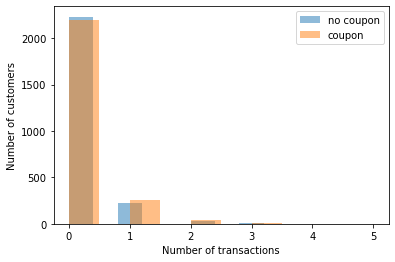

In [6]:
plt.hist(ABtest.loc[ABtest.test_coupon==0, "trans_after"], alpha=0.5, label="no coupon")
plt.hist(ABtest.loc[ABtest.test_coupon==1, "trans_after"], alpha=0.5, label="coupon")
plt.xlabel("Number of transactions")
plt.ylabel("Number of customers")
plt.legend()
plt.show()

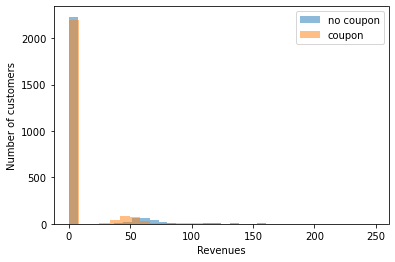

In [7]:
plt.hist(ABtest.loc[ABtest.test_coupon==0, "revenue_after"], alpha=0.5, bins=30, label="no coupon")
plt.hist(ABtest.loc[ABtest.test_coupon==1, "revenue_after"], alpha=0.5, bins=30, label="coupon")
plt.xlabel("Revenues")
plt.ylabel("Number of customers")
plt.legend()
plt.show()

# Regression-Based Hypothesis Testing

We can do more than simply comparing the means and histograms of the two groups. To see the impact of **test_coupon** on the two outcomes, we can regress one or both of these quantities on **test_coupon** and investigate the results.

Let's regress **trans_after** on **test_coupon**. These are count data, and based on our visualization above, a simple Poisson or NBD model may work best.

In [8]:
negativebinomial("trans_after~test_coupon", ABtest).fit().summary()

Optimization terminated successfully.
         Current function value: 0.420155
         Iterations: 7
         Function evaluations: 9
         Gradient evaluations: 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:            trans_after   No. Observations:                 5000
Model:               NegativeBinomial   Df Residuals:                     4998
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                0.001156
Time:                        15:06:54   Log-Likelihood:                -2100.8
converged:                       True   LL-Null:                       -2103.2
Covariance Type:            nonrobust   LLR p-value:                   0.02745
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -2.0739      0.063    -32.939      0.000      -2.197      -1.950
test_coupon     0.1892      0.086      2.203      0.028       0.021       0.357
alpha           1.9466      0.296      6.586      0.000       1.367       2.526
===============================================================================
"""

It appears that coupons *do* impact the number of transactions made. Both models above indicate that, on average, giving a customer a coupon increases the number of transactions by a factor of $\exp(0.19) \approx 1.2$, which is what we saw with the means.

We can (and should) also estimate this model with the other covariates included, in order to test its robustness.

In [9]:
model = "trans_after~test_coupon"
for i in ABtest.columns[4:]:
    model+="+"+i

negativebinomial(model, ABtest).fit().summary()

         Current function value: 0.349688
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38


C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:            trans_after   No. Observations:                 5000
Model:               NegativeBinomial   Df Residuals:                     4992
Method:                           MLE   Df Model:                            7
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1687
Time:                        15:07:15   Log-Likelihood:                -1748.4
converged:                      False   LL-Null:                       -2103.2
Covariance Type:            nonrobust   LLR p-value:                6.067e-149
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.9578      0.172    -23.069      0.000      -4.294      -3.622
test_coupon             0.2002      0.082      2.433      0.015       0.039       0.361
channel_acq             0.3451      0.037      9.332      0.000       0.273       0.418
num_past_purch          0.2173      0.012     18.261      0.000       0.194       0.241
spent_last_purchase     0.0008      0.001      1.055      0.292      -0.001       0.002
weeks_since_visit      -0.1518      0.019     -8.098      0.000      -0.189      -0.115
browsing_minutes        0.0230      0.006      3.920      0.000       0.012       0.035
shopping_cart           1.1500      0.084     13.703      0.000       0.986       1.315
alpha                   0.3826      0.107      3.588      0.000       0.174       0.592
=======================================================================================
"""

# Customer Segmentation

We may wonder whether sending coupons to all customers may be the best idea. There may be certain segments of customers that would respond more positively to coupons than others. 

To tease these effects out, we can specify *interaction terms* in our models. The coefficients for these terms will tell us the output response conditional on a coupon being provided to the customer. We can then compare these coefficients to those estimated without conditioning on coupon.

In [10]:
model = "trans_after~test_coupon+channel_acq"
for i in ABtest.columns[4:]:
    model+="+"+i+"+test_coupon:"+i

negativebinomial(model, ABtest).fit().summary()

         Current function value: 0.348242
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37


C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:            trans_after   No. Observations:                 5000
Model:               NegativeBinomial   Df Residuals:                     4986
Method:                           MLE   Df Model:                           13
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1721
Time:                        15:07:46   Log-Likelihood:                -1741.2
converged:                      False   LL-Null:                       -2103.2
Covariance Type:            nonrobust   LLR p-value:                2.551e-146
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.8911      0.242    -16.110      0.000      -4.364      -3.418
test_coupon                         0.0707      0.324      0.218      0.827      -0.563       0.705
channel_acq                         0.3177      0.053      5.983      0.000       0.214       0.422
test_coupon:channel_acq             0.0538      0.073      0.740      0.459      -0.089       0.196
num_past_purch                      0.2453      0.016     15.166      0.000       0.214       0.277
test_coupon:num_past_purch         -0.0543      0.021     -2.528      0.011      -0.096      -0.012
spent_last_purchase                 0.0016      0.001      1.342      0.180      -0.001       0.004
test_coupon:spent_last_purchase    -0.0012      0.002     -0.742      0.458      -0.004       0.002
weeks_since_visit                  -0.1622      0.028     -5.836      0.000      -0.217      -0.108
test_coupon:weeks_since_visit       0.0162      0.037      0.434      0.664      -0.057       0.089
browsing_minutes                    0.0193      0.009      2.194      0.028       0.002       0.037
test_coupon:browsing_minutes        0.0066      0.012      0.559      0.576      -0.016       0.030
shopping_cart                       0.9649      0.122      7.912      0.000       0.726       1.204
test_coupon:shopping_cart           0.3319      0.166      1.995      0.046       0.006       0.658
alpha                               0.3295      0.107      3.066      0.002       0.119       0.540
===================================================================================================
"""

Looking at the estimated interaction term parameters, **test_coupon:num_past_purch** and **test_coupon:shopping_cart** both appear to be statistically significant. In particular, the former coefficient has the opposite sign from just **num_past_purch** alone. 

This tells us that while **test_coupon** and **num_past_purch** both contribute positively to the number of transactions, having **test_coupon** with larger values of **num_past_purch** may actually start contributing *negatively*. 

For example, suppose **num_past_purch** $=2$. If we give this customer a coupon, their utility changes by $$\beta_{test\_coupon}+2\beta_{test\_coupon:num\_past\_purch} = -.0379.$$
The utility decreases even more for larger values of **num_past_purch**. This suggests that it may only be worthwhile to give customers a coupon when they have 0 or 1 past purchases.

We can go back to our data and see these interactions. For each value of **num_past_purch**, we can compute the average value of **trans_after** in the data. We can do this separately for **test_coupon** $=0$ and **test_coupon** $=1$.

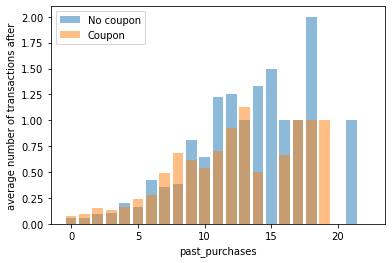

In [12]:
No_coupon = ABtest[ABtest.test_coupon==0].groupby("num_past_purch").mean()["trans_after"]
Coupon = ABtest[ABtest.test_coupon==1].groupby("num_past_purch").mean()["trans_after"]
plt.bar(No_coupon.index, No_coupon, alpha=0.5, label="No coupon")   
plt.bar(Coupon.index, Coupon, alpha=0.5, label="Coupon")  
plt.xlabel("past_purchases")
plt.ylabel("average number of transactions after")
plt.legend( )  
plt.show()